# DoWhy-4 — Le confondeur non observé : sensibilité, pas certitude

DoWhy-1 exigeait un estimand **nommé** ; DoWhy-3 découvrait le graphe avec sa
borne structurelle (le CPDAG ambigu). Il reste l'hypothèse qu'aucun graphe
observé ne peut trancher : **l'absence de confondeur NON OBSERVÉ**. On ne
peut ni la tester, ni la découvrir — on peut la **chiffrer**.

L'énoncé cible de ce notebook (issue #14049) :

> « Quelle force devrait avoir un confondeur caché pour annuler cet effet ? »

— **un chiffre, pas une réserve rhétorique**. Trois formalisations SOTA de la
même question, toutes réellement exécutées par `dowhy` (0.14) :

| Formalisation | Moteur | Monde | Le chiffre |
|---|---|---|---|
| Robustness value (R² partiel) | `refute_estimate` → `linear-partial-R2` | continu | le R² partiel minimal qui annule |
| E-value (Ding & VanderWeele) | `refute_estimate` → `e-value` | binaire (RR) | le RR minimal qui annule |
| Bornes de Rosenbaum (Γ) | calcul exact binomial sur paires | binaire apparié | le Γ* qui rend non significatif |

Et le pont concret : `direct-simulation` — un confondeur simulé de force
croissante, et la **courbe de bascule** de l'estimé ajusté.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

_fichier_organe = next(Path.cwd().rglob("dowhy_sensitivity_organs.py"))
sys.path.insert(0, str(_fichier_organe.parent))
import dowhy_sensitivity_organs as dso

pd.set_option("display.precision", 3)
print("organe :", _fichier_organe.parent.name)

organe : Causal-Bridges


## 1. Le monde A — l'analyste et son angle mort

Un traitement continu $X$, une issue continue $Y$, un confondeur **observé**
$C$ — et un confondeur **caché** $U$ que l'analyste ne mesure pas :

$$X = 0.7\,U + 0.5\,C + \varepsilon_X \qquad Y = 0.5\,X + 0.9\,U + 0.4\,C + \varepsilon_Y$$

L'effet vrai vaut $\tau = 0.5$. L'analyste ajuste sur $\{C\}$ — le mieux
qu'il puisse faire avec ses données. Le générateur expose deux vues : la vue
**analyste** (`X, Y, C`) et la vue **oracle** (avec `U`), qui servira de
vérité terrain.

In [2]:
df_monde = dso.generer_donnees_continues(n=2000, seed=42)
df_oracle = dso.generer_donnees_continues(n=2000, seed=42, cacher_u=False)

print("vue analyste :", list(df_monde.columns))
df_monde.head()

vue analyste : ['X', 'Y', 'C']


,X,Y,C
0,-0.594,-0.900,-0.675
1,-0.191,-0.719,-0.145
2,0.070,-0.359,-0.792
3,1.243,1.485,-0.308
4,-2.068,-2.152,-1.894


### L'estimé naïf

`dowhy` identifie l'ajustement backdoor $\{C\}$ et estime par régression
linéaire. C'est l'estimé que publierait l'étude : significatif, propre,
bref — et biaisé par $U$.

In [3]:
res_naif = dso.estimer_effet_continu(df_monde)
print(f"estime naive (ajustement C) = {res_naif.value:.3f}")
print(f"IC 95 %                  = [{res_naif.ic[0]:.3f}, {res_naif.ic[1]:.3f}]")
print(f"effet vrai (simulateur)  = {dso.TAU_VRAI}")

estime naive (ajustement C) = 1.159
IC 95 %                  = [1.116, 1.202]
effet vrai (simulateur)  = 0.5


### L'oracle — ce que l'analyste ne peut PAS faire

Par construction du monde, ajuster sur $\{C, U\}$ restaure l'effet vrai.
L'écart entre naïf et oracle mesure le travail que $U$ fait en silence.

In [4]:
from dowhy import CausalModel

modele_oracle = CausalModel(data=df_oracle, treatment="X", outcome="Y", common_causes=["C", "U"])
estimand_oracle = modele_oracle.identify_effect(proceed_when_unidentifiable=True)
estime_oracle = modele_oracle.estimate_effect(estimand_oracle, method_name="backdoor.linear_regression")
print(f"oracle (ajustement C+U)  = {estime_oracle.value:.3f}   (effet vrai {dso.TAU_VRAI})")
print(f"biais du a U             = {res_naif.value - estime_oracle.value:+.3f}")

oracle (ajustement C+U)  = 0.532   (effet vrai 0.5)
biais du a U             = +0.627


## 2. La robustness value — le R² partiel qui annule

Question : *quelle force un confondeur caché devrait-il avoir pour annuler
cet effet ?* Cinelli & Hazlett (2020) y répondent par la **robustness
value** : le $R^2$ partiel minimal qu'un confondeur devrait avoir **avec le
traitement ET avec l'issue** (après ajustement de $\{C\}$, à force égale
des deux côtés) pour ramener l'estimé à zéro. `dowhy` la calcule via le
refuter `add_unobserved_common_cause` en mode `linear-partial-R2`.

- `robustness_value` : annuler l'estimé (le ramener à 0) ;
- `robustness_value_alpha` : le rendre statistiquement non significatif.

In [5]:
rob = dso.robustesse_partielle_r2(res_naif.model, res_naif.estimand, res_naif.estimate)
print(f"robustness value (annuler)             = {rob.robustness_value:.3f}")
print(f"robustness value (non significatif)    = {rob.robustness_value_alpha:.3f}")
print(f"R2 partiel de X avec Y | C             = {rob.r2yt_w:.3f}")

robustness value (annuler)             = 0.677
robustness value (non significatif)    = 0.665
R2 partiel de X avec Y | C             = 0.587


### La vérité terrain : le R² partiel **réel** de U

Le RV est un seuil ; il ne dit rien des confondeurs qui existent. Mais notre
monde est simulé : sur la vue oracle, on **mesure** le $R^2$ partiel réel de
$U$ — avec $X$ (après $C$) et avec $Y$ (après $X, C$) — et on le compare au
seuil. C'est le geste que le praticien remplace par sa connaissance du
domaine : « un cache aussi fort que *tel* facteur connu ».

In [6]:
r2_u_x = dso.r2_partiel(df_oracle, "X", "U", ["C"])
r2_u_y = dso.r2_partiel(df_oracle, "Y", "U", ["X", "C"])
print(f"R2 partiel reel de U avec X | C    = {r2_u_x:.3f}")
print(f"R2 partiel reel de U avec Y | X,C  = {r2_u_y:.3f}")
print(f"robustness value                   = {rob.robustness_value:.3f}")

verdict_a = dso.verdict_sensibilite(r2_u_x, r2_u_y, rob)
print(f"\nverdict : {verdict_a['verdict']}")
print(verdict_a['message'])

R2 partiel reel de U avec X | C    = 0.493
R2 partiel reel de U avec Y | X,C  = 0.427
robustness value                   = 0.677

verdict : SURVIT_A_CE_CONFOUNDEUR
RESULTAT : l'association survit a ce confondeur -- meme a force egale des deux cotes au niveau de son cote le plus fort (0.49 < RV 0.68), le cache n'annule pas l'estime. ATTENTION : survivre a l'annulation n'est pas etre juste -- l'estime reste biaisé tant que le confondeur n'est pas mesure.


### Survivre n'est pas être juste

Le verdict dit que l'association **survit** à un confondeur de la force de
$U$ : même à force égale des deux côtés au niveau de son côté le plus fort
(0.49 < 0.68), le cache n'annule pas l'estimé. Mais le tableau des trois
nombres raconte l'histoire complète :

| quantité | valeur | rôle |
|---|---|---|
| estimé naïf | 1.159 | ce que l'étude publie |
| oracle $\{C, U\}$ | 0.532 | l'effet vrai du simulateur |
| robustness value | 0.677 | la force qui annulerait |
| $R^2$ réel de $U$ | 0.49 / 0.43 | la force du cache **réel** |

$U$ réduit l'estimé de moitié sans pouvoir l'annuler : **la sensibilité
chiffre l'attaque, elle ne certifie pas l'estimé**.

In [7]:
synthese_a = pd.DataFrame({
    "quantite": ["estime naif (ajuste C)", "oracle (ajuste C+U)", "effet vrai",
                 "robustness value", "R2 reel U avec X", "R2 reel U avec Y"],
    "valeur": [res_naif.value, estime_oracle.value, dso.TAU_VRAI,
               rob.robustness_value, r2_u_x, r2_u_y],
})
synthese_a

,quantite,valeur
0,estime naif (ajuste C),1.159
1,oracle (ajuste C+U),0.532
2,effet vrai,0.500
3,robustness value,0.677
4,R2 reel U avec X,0.493
5,R2 reel U avec Y,0.427


## 3. Le confondeur simulé — voir la bascule

Le refuter `direct-simulation` rend le mécanisme concret : on injecte dans
les données un confondeur gaussien $U^*$ de coefficient $\kappa_t$ sur $X$
et $\kappa_y$ sur $Y$, puis on ré-estime l'effet backdoor **avec $U^*$ dans
l'ensemble d'ajustement**. Quand $\kappa_y$ croît, l'estimé ajusté descend —
la **courbe de bascule**. Le point de franchissement de zéro est le chiffre
cherché, en unités du monde (coefficients de régression).

D'abord à $\kappa_t = 0.7$ fixé (la force réelle de $U$ sur $X$) :

In [8]:
bascule_kt = dso.confondeur_simule(res_naif.model, res_naif.estimand, res_naif.estimate,
                                   k_fixe=0.7, k_max=1.8, pas=0.2)
print(bascule_kt.to_string(index=False))
kappa_kt = dso.kappa_bascule(bascule_kt)
print(f"\nkappa de bascule (kappa_t=0.7) = {kappa_kt:.2f}")

  k  kappa_t  estime_ajuste
0.0      0.7          0.755
0.2      0.7          0.674
0.4      0.7          0.562
0.6      0.7          0.482
0.8      0.7          0.391
1.0      0.7          0.265
1.2      0.7          0.212
1.4      0.7          0.093
1.6      0.7         -0.034
1.8      0.7         -0.043



kappa de bascule (kappa_t=0.7) = 1.55


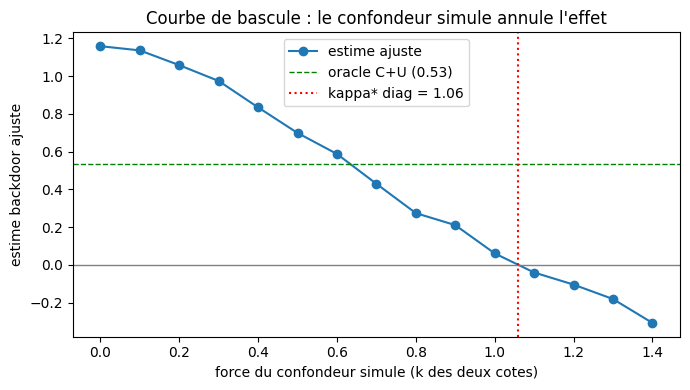

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

bascule_diag = dso.confondeur_simule(res_naif.model, res_naif.estimand, res_naif.estimate,
                                     k_max=1.4, pas=0.1, diagonale=True)
kappa_diag = dso.kappa_bascule(bascule_diag)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bascule_diag["k"], bascule_diag["estime_ajuste"], "o-", label="estime ajuste")
ax.axhline(0.0, color="gray", lw=1)
ax.axhline(estime_oracle.value, color="green", ls="--", lw=1, label=f"oracle C+U ({estime_oracle.value:.2f})")
if kappa_diag is not None:
    ax.axvline(kappa_diag, color="red", ls=":", label=f"kappa* diag = {kappa_diag:.2f}")
ax.set_xlabel("force du confondeur simule (k des deux cotes)")
ax.set_ylabel("estime backdoor ajuste")
ax.set_title("Courbe de bascule : le confondeur simule annule l'effet")
ax.legend()
plt.tight_layout()
plt.show()

**Le rapport de forces.** À force égale des deux côtés, il faut
$\kappa \approx 1.1$ pour annuler l'association — deux fois la force réelle
de $U$ sur $X$ (0.7). Un résultat contre-intuitif mérite d'être mesuré :
**renforcer $U$ ne rend PAS l'association plus fragile**. Si $U$ est plus
fort, l'association observée grossit *avec* lui, et la robustness value
monte (mesuré : $U$ à 1.8/1.8 → RV 0.89 ; à 2.6/2.6 → RV 0.94). Le RV
mesure un *rapport* de forces, pas une constante — c'est l'objet de
l'exercice 1.

## 4. Le monde B — risques relatifs et E-value

Le monde continu parlait en $R^2$ ; l'épidémiologie parle en **risques
relatifs**. Nouveau monde : $X$ binaire (exposé/non exposé), $Y$ binaire et
**rare** (~7 %), risques multiplicatifs (lien log) — le RR conditionnel vrai
vaut $e^{0.4} \approx 1.49$, et le GLM de Poisson à lien log de `dowhy` est
bien spécifié.

In [10]:
df_binaire = dso.generer_donnees_binaires(n=3000, seed=42)
print(f"P(Y=1) = {df_binaire['Y'].mean():.3f} (issue rare)")
print(f"P(X=1) = {df_binaire['X'].mean():.3f}")
rr_brut = df_binaire.groupby("X")["Y"].mean()[1] / df_binaire.groupby("X")["Y"].mean()[0]
print(f"RR brut = {rr_brut:.3f}   RR vrai (simulateur) = {np.exp(dso.B_X):.3f}")

P(Y=1) = 0.072 (issue rare)
P(X=1) = 0.508
RR brut = 1.823   RR vrai (simulateur) = 1.492


### Le RR ajusté — et un piège de l'API

`dowhy` estime le RR par `backdoor.generalized_linear_model` (Poisson, lien
log) en ajustant $\{C\}$. **Piège mesuré** : `estimate.value` rend un
contraste *marginal* sur l'échelle des probabilités prédites (~1.04), pas le
RR — le log-RR se lit sur le **coefficient** du traitement (l'organe
l'encapsule). Le $U$ caché fait monter le RR ajusté au-dessus du vrai.

In [11]:
rr = dso.estimer_rr_binaire(df_binaire)
print(f"RR ajuste C (coefficient) = {rr.rr:.3f}   IC 95 % [{rr.rr_inf:.3f}, {rr.rr_sup:.3f}]")
print(f"RR vrai (simulateur)      = {np.exp(dso.B_X):.3f}")
print(f"contraste marginal .value = {rr.estimate.value:.3f}  <- PAS le RR (piege encapsule)")

RR ajuste C (coefficient) = 1.790   IC 95 % [1.352, 2.371]
RR vrai (simulateur)      = 1.492
contraste marginal .value = 0.041  <- PAS le RR (piege encapsule)


### L'E-value — le RR minimal qui annule

L'E-value de Ding & VanderWeele (2017) : la force d'association minimale,
**sur l'échelle des risques relatifs**, qu'un confondeur caché devrait avoir
**avec le traitement ET avec l'issue** (conditionnellement aux covariables
mesurées) pour expliquer *entièrement* l'association. `dowhy` l'implémente
des packages R `EValue`/`tipr`, avec deux lectures :

- pour l'estimé ponctuel : un cache de RR ≥ E-value des deux côtés annule ;
- pour la borne d'IC la plus proche de 1 : un cache plus faible suffit déjà.

Et le **benchmark de McGowan & Greevy** : on retire chaque covariable
mesurée, on ré-estime, on mesure le déplacement — l'« E-value observé » de
$C$ donne l'échelle des forces *réelles* de l'étude.

In [12]:
ev = dso.sensibilite_e_value(rr.model, rr.estimand, rr.estimate)
print(f"RR converti               = {ev.rr_converti:.3f}")
print(f"E-value (estime)          = {ev.evalue_estime:.2f}")
print(f"E-value (borne d'IC)      = {ev.evalue_ic_limite:.2f}")
print("\nbenchmark McGowan-Greevy (retirer la covariable, re-estimer) :")
print(ev.benchmarking.round(3).to_string())

RR converti               = 1.790
E-value (estime)          = 2.98
E-value (borne d'IC)      = 2.04

benchmark McGowan-Greevy (retirer la covariable, re-estimer) :
                   converted_est  converted_lower_ci  converted_upper_ci  observed_covariate_e_value
dropped_covariate                                                                                   
C                          1.823               1.378               2.413                        1.16


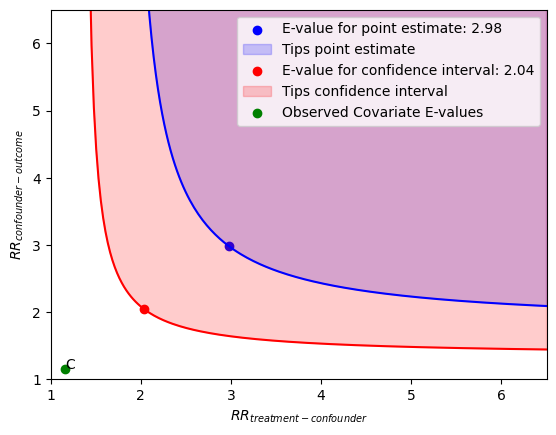

In [13]:
# les contours de bascule : (RR cache-traitement) x (RR cache-issue) qui annulent
ev.analyzer.plot(xy_limit=6.5)
plt.show()

In [14]:
verdict_b = dso.verdict_e_value(ev)
print(f"verdict : {verdict_b['verdict']} (rapport {verdict_b['rapport']:.2f}x)")
print(verdict_b['message'])

# controle independent : la formule fermee de VanderWeele-Ding
rr_conv = ev.rr_converti
evalue_formule = rr_conv + (rr_conv * (rr_conv - 1)) ** 0.5
print(f"\nformule RR + sqrt(RR(RR-1)) = {evalue_formule:.4f} vs dowhy {ev.evalue_estime:.4f}")

verdict : ROBUSTE_RELATIVEMENT_AUX_OBSERVES (rapport 2.57x)
RESULTAT : E-value 2.98 contre un maximum observe de 1.16 -- un confondeur cache devrait etre 2.6x plus fort (echelle E-value) que le meilleur confondeur mesure pour annuler l'association. La robustesse est relative aux forces observees dans CETTE etude, pas une certification d'absence de confondeur.

formule RR + sqrt(RR(RR-1)) = 2.9796 vs dowhy 2.9796


**Lire un E-value nu est impossible** — « 3.0, c'est grand ? » n'a pas de
réponse universelle. Le benchmark répond : le meilleur confondeur *mesuré*
de cette étude ($C$, qui fait pourtant passer le RR de 1.49 à 1.79) a un
E-value observé de **1.16**. Un cache qui annulerait devrait être **2.6×
plus fort que ce confondeur réel**. La robustesse est *relative aux forces
observées dans l'étude* — un résultat, pas une certification.

## 5. Les bornes de Rosenbaum — Γ*, le déséquilibre qui masque

Troisième formalisation, sur **paires appariées** : on apparie exactement
chaque exposé à un non-exposé de même strate de $C$. Seules les paires
**discordantes** (l'un malade, l'autre sain) renseignent : sous l'hypothèse
nulle sans biais caché, chacune est un tirage à pile ou face. Un
déséquilibre caché $\Gamma$ borne la probabilité d'un tirage dans
$[1/(1+\Gamma), \Gamma/(1+\Gamma)]$ — d'où des **bornes exactes** de la
p-valeur du test du signe (Rosenbaum 2002, chap. 4 ; calcul binomial
exact, il n'existe pas de package Python établi pour cette borne).

In [15]:
discordantes = dso.paires_appariees(df_binaire, seed=0)
m, s = len(discordantes), int(discordantes.sum())
p_obs = dso.bornes_rosenbaum(s, m, 1.0)[1]
print(f"paires discordantes m = {m} ; succes (traite malade) s = {s}")
print(f"p-valeur observee (Gamma=1) = {p_obs:.2e}")

paires discordantes m = 193 ; succes (traite malade) s = 122
p-valeur observee (Gamma=1) = 1.48e-04


In [16]:
lignes = []
for g in (1.0, 1.33, 1.5, 2.0, 3.0):
    lo, hi = dso.bornes_rosenbaum(s, m, g)
    lignes.append({"Gamma": g, "p_basse": f"{lo:.1e}", "p_haute": f"{hi:.1e}"})
bornes = pd.DataFrame(lignes)
print(bornes.to_string(index=False))

gamma_etoile = dso.gamma_critique(s, m)
print(f"\nGamma* (borne haute croise 0.05) = {gamma_etoile:.2f}")

 Gamma p_basse p_haute
  1.00 1.5e-04 1.5e-04
  1.33 1.1e-08 4.9e-02
  1.50 6.6e-11 2.0e-01
  2.00 2.2e-17 8.6e-01
  3.00 4.8e-29 1.0e+00

Gamma* (borne haute croise 0.05) = 1.33


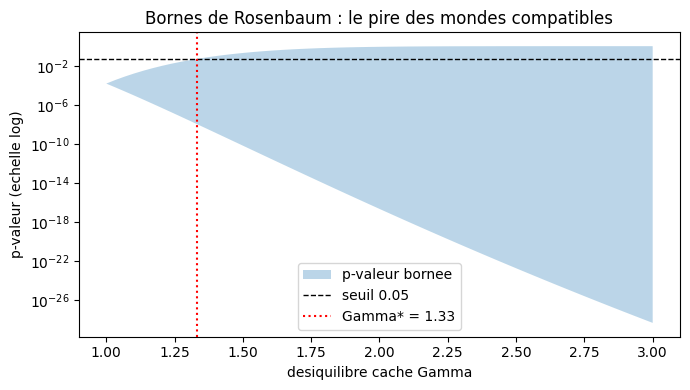

In [17]:
gammas = np.linspace(1.0, 3.0, 60)
p_hautes = [dso.bornes_rosenbaum(s, m, g)[1] for g in gammas]
p_basses = [dso.bornes_rosenbaum(s, m, g)[0] for g in gammas]

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(gammas, p_basses, p_hautes, alpha=0.3, label="p-valeur bornee")
ax.axhline(0.05, color="black", ls="--", lw=1, label="seuil 0.05")
ax.axvline(gamma_etoile, color="red", ls=":", label=f"Gamma* = {gamma_etoile:.2f}")
ax.set_yscale("log")
ax.set_xlabel("desiquilibre cache Gamma")
ax.set_ylabel("p-valeur (echelle log)")
ax.set_title("Bornes de Rosenbaum : le pire des mondes compatibles")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Synthèse — trois chiffres pour une même question

« Quelle force devrait avoir un confondeur caché pour annuler cet effet ? »

| Monde | Formalisation | Le chiffre | Contre quoi le lire |
|---|---|---|---|
| Continu (naïf 1.16) | robustness value | **0.68** de R² partiel | $R^2$ réel de $U$ : 0.49 |
| Continu (bascule) | $\kappa$ simulé | **1.5** ($\kappa_t = 0.7$) | coefficients du monde |
| Binaire (RR 1.79) | E-value | **2.98** | E-value observé de $C$ : 1.16 |
| Paires (m=193) | Rosenbaum | **Γ\* = 1.33** | Γ d'un biais plausible |

Ce que les trois formalisations s'accordent à dire : **la sensibilité ne
dit pas que l'effet est vrai — elle dit à quel point il est attaquable**.
L'association du monde A survit à son $U$ réel tout en étant réduite de
moitié ; l'association du monde B exige un cache bien plus fort que $C$,
mais un déséquilibre d'appariement modeste (Γ 1.33) suffirait à la masquer.
Un chiffre par monde, pas une réserve rhétorique.

## Exercice 1 — Le rapport de forces : renforcer U vs affaiblir l'effet

Deux intuitions à confronter aux mesures, sur le monde A :

1. **Renforcer le cache** : régénérer avec `coef_u_x=1.8, coef_u_y=1.8`.
   Mesurer naive, RV et R² réels de U — le verdict bascule-t-il ?
2. **Affaiblir le signal** : régénérer avec `tau=0.2, bruit_y=3.0`
   (l'effet vrai chute, le bruit monte). Mêmes mesures — et cette fois ?

Conclure : pourquoi le RV monte-t-il quand U se renforce, et pourquoi
affaiblir l'effet (pas renforcer le cache) rend l'association annulable ?

# attendu : cas 1 -> SURVIT (RV ~0.89 > R2U ~0.87) : l'association OBSERVEE grossit avec U
# attendu : cas 2 -> ANNULABLE (RV ~0.25 < R2U ~0.49) : meme un cache aussi fort que U annule

In [18]:
resultats_ex1 = None  # TODO etudiant
# Etape 1 : df_fort = dso.generer_donnees_continues(seed=42, cacher_u=False, coef_u_x=1.8, coef_u_y=1.8)
# Etape 2 : estimer + robustesse_partielle_r2 + r2_partiel + verdict_sensibilite (comme sections 1-2)
# Etape 3 : idem avec tau=0.2, bruit_y=3.0
# Indice : sur la vue cacher_u=False, estimer sur df[["X", "Y", "C"]] ; les R2 sur la vue complete

## Exercice 2 — L'E-value de l'IC et la taille d'échantillon

L'E-value de l'estimé (2.98) dépasse celui de l'IC (2.04). Refaire
l'analyse du monde B avec `n=10000` :

1. Pourquoi l'IC se resserre-t-il, et que fait l'E-value de **l'IC** ?
2. Pourquoi l'E-value de **l'estimé** bouge-t-il à peine ?

# attendu : IC plus etroit -> sa borne s'eloigne de 1 -> E-value(IC) MONTE vers l'E-value(estime)
# attendu : l'estime ponctuel converge (biais de U constant) -> son E-value est presque inchange

In [19]:
resultats_ex2 = None  # TODO etudiant
# Etape 1 : df_b_grand = dso.generer_donnees_binaires(n=10000, seed=42)
# Etape 2 : estimer_rr_binaire puis sensibilite_e_value, comparer a la section 4
# Indice : comparer (rr.rr_inf, ev.evalue_ic_limite, ev.evalue_estime) a n=3000 vs n=10000

## Exercice 3 — Γ* d'un effet plus faible

Reprendre le monde B avec `b_x=0.2` (RR vrai $e^{0.2} \approx 1.22$) :
ré-apparier, recompter $(m, s)$, recalculer Γ*. Comparer au Γ\* = 1.33 de
la section 5 et conclure : Γ* mesure-t-il la *vérité* de l'effet ou sa
*solidité statistique face au pire des mondes* ?

# attendu : effet plus faible -> Gamma* plus proche de 1 (un desequilibre cache plus faible suffit)
# attendu : Gamma* peut rester > 1 tant que l'effet est detectable : solidite, pas verite

In [20]:
resultats_ex3 = None  # TODO etudiant
# Etape 1 : df_b_faible = dso.generer_donnees_binaires(n=3000, seed=42, b_x=0.2)
# Etape 2 : paires_appariees -> (m, s) ; bornes_rosenbaum sur une grille ; gamma_critique
# Indice : dso.gamma_critique(s, m) suffit pour le chiffre ; verifier que m reste ~150-200

## À retenir

1. **L'hypothèse de non-confondance invérifiable se chiffre.** Trois
   formalisations (R² partiel, E-value, Γ de Rosenbaum), trois unités, une
   même question : *quelle force annulerait cet effet ?*
2. **Un seuil ne suffit pas : il faut l'échelle.** Le RV se lit contre les
   $R^2$ réels des variables connues ; l'E-value contre l'E-value observé
   des covariables mesurées ; Γ\* contre le Γ d'un biais plausible.
3. **Le rapport de forces est relatif.** Renforcer le confondeur caché
   renforce l'association observée : c'est affaiblir l'effet vrai (signal
   faible sous bruit) qui rend l'association annulable.
4. **Survivre n'est pas être juste.** Le monde A survit à son $U$ tout en
   étant réduit de moitié ; aucune analyse de sensibilité ne remplace la
   mesure du confondeur — elle dit combien elle coûte de l'ignorer.

Série DoWhy (retour au [README](README.md)) : DoWhy-1 l'estimand, DoWhy-2 le
contrefactuel, DoWhy-3 le graphe, **DoWhy-4 le confondeur caché**, DoWhy-5
l'instrument faible.